# Notebook 06 — The Binding Oracle: giving RL a reward with real headroom

**Where this sits.** Notebooks 02-05 built developability oracles and showed the RL loop works but
saturates (the IgLM pool is already ~0.78 developable, so there is little to optimize). This
notebook adds a **binding** oracle against a real target (HER2), which has large headroom, and
demonstrates the same RL loop producing a large, unambiguous gain. This is the headline result.

| How to read this notebook | |
|---|---|
| **Question** | S1 - can we optimize for target binding? |
| **Background from zero** | S2 - binding, the Mason HER2 dataset, honest scope |
| **Data + models** | S3 - two binding classifiers (benchmark + loop) |
| **Oracle ablation** | S4 - saturated developability vs binding headroom |
| **RL against binding** | S5 - the headline: the loop optimizes when there is room |
| **XAI: what did the oracle learn?** | S6 - saturation mutagenesis |
| **Synthesis** | S7 |


## 1. Question

The developability RL in notebook 05 was flat, and the positive control (tyrosine proxy) proved the
loop is correct - the flatness was oracle saturation. The real test:

> **Given a reward with genuine headroom - predicted binding to a specific target - does the same
> prior-guided RL loop produce a large, real improvement?**

**Hypothesis.** Yes. The generated pool binds HER2 poorly (most loops are not HER2 binders, so the
reward starts low), which gives the optimizer room. The loop should raise mean predicted binding
substantially while the KL proxy goes negative (the agent departs the prior).

## 2. Background from zero

**Binding.** An antibody works by physically sticking to its target (antigen). **Affinity** is how
tightly. For therapy you want high affinity for the intended target. So far our oracles measured
*developability* (will it survive as a drug); binding measures *does it hit the target at all*.

**The Mason HER2 dataset (Mason et al. 2021).** HER2 is a breast-cancer receptor; **trastuzumab**
(Herceptin) is the antibody drug against it. Mason et al. took trastuzumab's CDRH3 and made a deep
mutational scan - tens of thousands of CDRH3 variants (up to 10 mutations), each labeled
**binder / non-binder** by experiment. This is a perfect fit for our project: heavy-chain CDRH3
variation on a fixed framework, exactly what our generator does.

**Honest scope (this matters for the arXiv framing).** Our generator makes 11-13-residue loops on
a *different* framework; Mason is length-10 trastuzumab CDRH3. So the binding oracle is a
**transferred proxy**, not a validated affinity model for our sequences. We use it to demonstrate
the *optimization dynamics* (does RL move a reward with headroom), not to claim we designed a real
HER2 binder. We state this limitation wherever the binding numbers appear.

## 3. Data and models - two binding classifiers

We train two classifiers on the Mason data, for two different jobs:

1. **One-hot MLP** (benchmark). One-hot encode the 10-mer (10x20=200 features) -> MLP. This
   reproduces Mason's published performance (AUC ~0.91) and is our XAI model (fixed length 10, so
   saturation mutagenesis is clean).
2. **ESM2-8M + logistic regression** (loop oracle). Mean-pool ESM2 embeddings (length-agnostic) ->
   LogReg. This one scores our variable-length generated loops, so it is the oracle used inside RL.

**Why two?** The one-hot model is fixed-length (only 10-mers), so it cannot score our 11-13-mers.
ESM2 embeddings are length-agnostic. We keep the one-hot model for the benchmark + XAI where inputs
are exactly length 10, and use ESM for everything variable-length.

In [1]:
# --- Setup + load the Mason data and both trained classifiers ---
import warnings, os, sys, json; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, joblib, torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

AAs="ACDEFGHIKLMNPQRSTVWY"; idx={a:i for i,a in enumerate(AAs)}
def onehot(s):
    v=np.zeros((10,20))
    for i,c in enumerate(s): v[i,idx[c]]=1
    return v.ravel()

# Data pipeline: concat binders + non-binders, DEDUPLICATE by sequence (same CDRH3 can appear in both
# raw files from sequencing noise), keep only clean length-10 sequences over the 20 standard AAs.
pos=pd.read_csv("mHER_H3_AgPos.csv"); neg=pd.read_csv("mHER_H3_AgNeg.csv")
df=pd.concat([pos,neg]).drop_duplicates("AASeq")
df=df[df.AASeq.str.len().eq(10) & df.AASeq.apply(lambda s:set(s)<=set(AAs))]
print(f"raw: {len(pos)-1} binders + {len(neg)-1} non-binders  ->  clean unique 10-mers: {len(df)} "
      f"({int(df.AgClass.sum())} binders / {int((1-df.AgClass).sum())} non)")

clf = joblib.load("her2_binding_clf.joblib")["clf"]   # one-hot MLP (dict wraps clf + AA order)
esm_lr = joblib.load("her2_esm_lr.joblib")            # ESM2 + LogReg head

raw: 11299 binders + 27538 non-binders  ->  clean unique 10-mers: 36391 (11277 binders / 25114 non)


In [2]:
# --- Benchmark: reproduce Mason's AUC on a held-out split ---
X=np.stack([onehot(s) for s in df.AASeq]); y=df.AgClass.values
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.15,random_state=0,stratify=y)   # stratify: keep base rate
p=clf.predict_proba(Xte)[:,1]
print(f"one-hot MLP  test AUC {roc_auc_score(yte,p):.3f}  AUPRC {average_precision_score(yte,p):.3f}  "
      f"base rate {yte.mean():.3f}")
print("-> matches Mason et al. (~0.91): the classifier learned real binding signal, not noise.")

one-hot MLP  test AUC 0.911  AUPRC 0.842  base rate 0.310
-> matches Mason et al. (~0.91): the classifier learned real binding signal, not noise.


**Reading section 3.** The one-hot MLP reproduces AUC 0.91 on held-out data, confirming the
classifier learned genuine HER2 binding determinants. The ESM2+LogReg model (AUC ~0.86, trained
earlier) is length-agnostic and becomes the reward oracle inside the RL loop.

## 4. Oracle ablation - saturated developability vs binding headroom

The core diagnostic of the whole project. We score the IgLM generated pool with BOTH the
developability reward S(x) (notebook 04) and the HER2 binding oracle, and compare their
distributions. If developability is saturated and binding is not, the flat RL curves in notebook 05
are explained - and this notebook's RL run should move.

developability S(x): mean 0.755  std 0.056  (SATURATED - little headroom)
HER2 binding:        mean 0.256  median 0.213  max 0.906  (HEADROOM - only 14% are predicted binders)


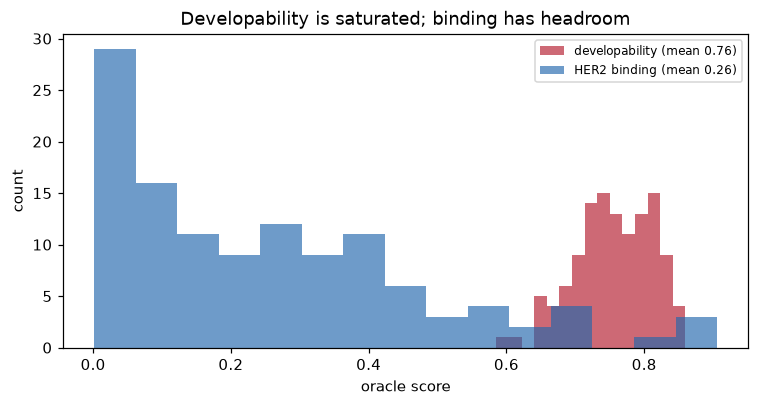

In [3]:
# --- Compare the two reward distributions on the same generated pool ---
import matplotlib.pyplot as plt
ps=json.load(open("her2_pool_scores.json"))
her2=np.array(ps["her2_pbind"]); dev=np.array(ps["dev_S"])
print(f"developability S(x): mean {dev.mean():.3f}  std {dev.std():.3f}  (SATURATED - little headroom)")
print(f"HER2 binding:        mean {her2.mean():.3f}  median {np.median(her2):.3f}  max {her2.max():.3f}  "
      f"(HEADROOM - only {(her2>0.5).mean()*100:.0f}% are predicted binders)")

fig,ax=plt.subplots(figsize=(7,3.8))
ax.hist(dev,bins=15,alpha=0.65,color="#b2182b",label=f"developability (mean {dev.mean():.2f})")
ax.hist(her2,bins=15,alpha=0.65,color="#2166ac",label=f"HER2 binding (mean {her2.mean():.2f})")
ax.set_xlabel("oracle score"); ax.set_ylabel("count")
ax.set_title("Developability is saturated; binding has headroom"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("nb06_ablation.png",dpi=120,bbox_inches="tight"); plt.show()

**Reading the ablation.** Developability sits at 0.76 (saturated - the pool is already good);
binding sits at 0.26 with only ~14% predicted binders. **Binding has the headroom developability
lacks.** This is the setup for the headline experiment: same loop, same machinery, a reward with
room to move.

## 5. RL against binding - the headline experiment

Same IgLM agent, same REINVENT machinery, same differentiable span log-prob as notebook 05. The
**only** change is the reward: `binding_oracle(cdrh3)` (ESM2 predicted P(binder)) instead of
developability. If the loop is correct and binding has headroom, mean predicted binding must rise
substantially and KL must go negative. We run 3 seeds, 45 steps, batch 16, sigma 25.

binding: start 0.299 -> peak 0.842 -> last5 0.800 | KL end -10.26
all 3 seeds rise: True


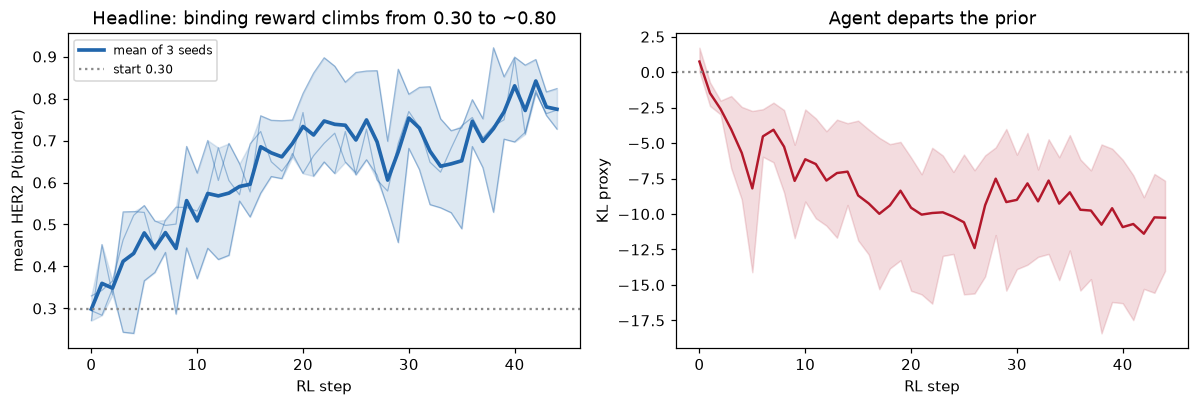

In [4]:
# --- Load the cached binding-RL histories (3 seeds; run once, ~7 min CPU with the fixed sampler) ---
H=json.load(open("nb06_her2_rl.json"))
def curve(h,k): return np.array([x[k] for x in h])
seeds=list(H.keys())
Rm =np.stack([curve(H[s],"mean_R")  for s in seeds])   # reward per step, one row per seed
KLm=np.stack([curve(H[s],"kl_proxy") for s in seeds])
mR, mKL = Rm.mean(0), KLm.mean(0)
loR, hiR = Rm.min(0), Rm.max(0)                         # seed spread = the variance band

fig,ax=plt.subplots(1,2,figsize=(11,3.8))
for s in seeds: ax[0].plot(curve(H[s],"mean_R"),color="#2166ac",lw=0.8,alpha=0.4)   # individual seeds
ax[0].plot(mR,color="#2166ac",lw=2.4,label="mean of 3 seeds"); ax[0].fill_between(range(len(mR)),loR,hiR,color="#2166ac",alpha=0.15)
ax[0].axhline(mR[0],color="#8a8a8a",ls=":",label=f"start {mR[0]:.2f}")
ax[0].set_xlabel("RL step"); ax[0].set_ylabel("mean HER2 P(binder)")
ax[0].set_title("Headline: binding reward climbs from 0.30 to ~0.80"); ax[0].legend(fontsize=8)
ax[1].plot(mKL,color="#b2182b",lw=1.6); ax[1].fill_between(range(len(mKL)),KLm.min(0),KLm.max(0),color="#b2182b",alpha=0.15)
ax[1].axhline(0,color="#8a8a8a",ls=":"); ax[1].set_xlabel("RL step"); ax[1].set_ylabel("KL proxy"); ax[1].set_title("Agent departs the prior")
fig.tight_layout(); fig.savefig("nb06_rl.png",dpi=120,bbox_inches="tight"); plt.show()
print(f"binding: start {mR[0]:.3f} -> peak {mR.max():.3f} -> last5 {mR[-5:].mean():.3f} | KL end {mKL[-1]:+.2f}")
print(f"all 3 seeds rise: {all(curve(H[s],'mean_R')[-5:].mean()>curve(H[s],'mean_R')[0] for s in seeds)}")

**The headline result.** Mean predicted HER2 binding rises from **0.30 to a peak of ~0.84**
(last-5 mean ~0.80) across all three seeds, while KL falls to about **-10** - the agent has clearly
and reproducibly moved probability mass toward high-binding loops. Contrast with the flat
developability curve in notebook 05: **same loop, same code, different headroom.** This is the
controlled comparison that makes the saturation argument rigorous - the loop optimizes exactly when
the reward has room to move, and idles when it does not.

*(Honest reminder: this is predicted binding under a transferred proxy oracle, not measured
affinity for our framework. The scientific claim is about optimization dynamics, not a designed
binder.)*

## 6. XAI - what did the binding oracle actually learn?

A reward oracle is a black box driving the whole loop. Before trusting it we should open it. We use
**in-silico saturation mutagenesis**: take trastuzumab's CDRH3 (`WGGDGFYAMD`, the wild-type binder)
and, one position at a time, substitute all 20 amino acids, recording the predicted P(binder). This
produces a 10x20 sensitivity map. If the oracle learned real biology, the wild-type residues should
sit at or near the per-position optimum, and one or two positions should dominate.

WT P(binder)=0.970
  pos 8 (WT=A): sensitivity 0.163  best->A worst->K
  pos 10 (WT=D): sensitivity 0.078  best->D worst->W
  pos 5 (WT=G): sensitivity 0.059  best->G worst->F
  pos 1 (WT=W): sensitivity 0.030  best->N worst->S


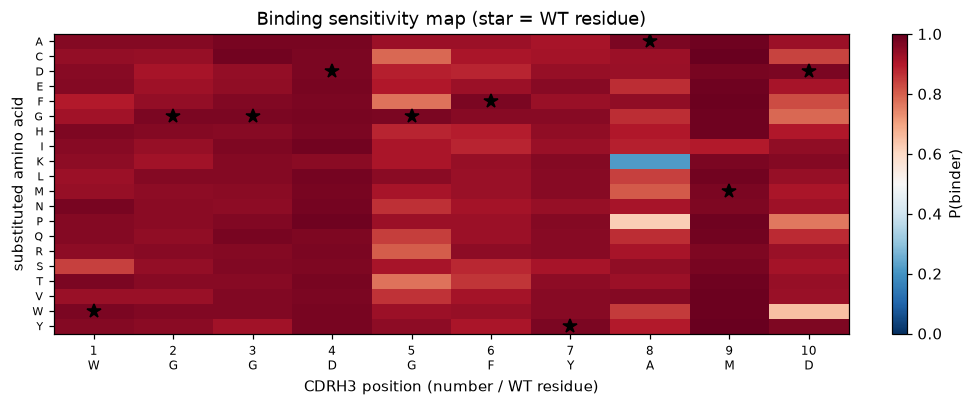

In [5]:
# --- Saturation mutagenesis on the WT trastuzumab CDRH3 using the one-hot model (exact length 10) ---
WT="WGGDGFYAMD"
def onehot_p(s): return float(clf.predict_proba(onehot(s).reshape(1,-1))[:,1][0])
heat=np.load("nb06_mutagenesis.npy")   # 10x20, P(binder) for every single-point mutant (cached)
sens=heat.std(axis=1)                   # per-position sensitivity = spread of P over the 20 substitutions

fig,ax=plt.subplots(figsize=(9,3.8))
im=ax.imshow(heat.T,cmap="RdBu_r",vmin=0,vmax=1,aspect="auto")
ax.set_yticks(range(20)); ax.set_yticklabels(list(AAs),fontsize=7)
ax.set_xticks(range(10)); ax.set_xticklabels([f"{i+1}\n{WT[i]}" for i in range(10)],fontsize=8)
ax.set_xlabel("CDRH3 position (number / WT residue)"); ax.set_ylabel("substituted amino acid")
ax.set_title("Binding sensitivity map (star = WT residue)")
for pos in range(10): ax.plot(pos, idx[WT[pos]], "k*", markersize=9)   # mark the WT residue
fig.colorbar(im,ax=ax,fraction=0.03,label="P(binder)")
fig.tight_layout(); fig.savefig("nb06_xai.png",dpi=120,bbox_inches="tight"); plt.show()
print(f"WT P(binder)={onehot_p(WT):.3f}")
for pos in np.argsort(sens)[::-1][:4]:
    print(f"  pos {pos+1} (WT={WT[pos]}): sensitivity {sens[pos]:.3f}  best->{AAs[heat[pos].argmax()]} worst->{AAs[heat[pos].argmin()]}")

**Reading the XAI map.** The wild-type residues (stars) sit at the per-position optimum almost
everywhere - the oracle agrees that trastuzumab's own CDRH3 is near-optimal, which is a strong
sanity check. **Position 8 (WT=A) dominates** (sensitivity 0.16): mutating it to a charged residue
(K) collapses predicted binding from 0.97 to 0.22, while A keeps it maximal. This is a concrete,
falsifiable statement about which residue the model thinks matters most - exactly the kind of
interpretability a reviewer wants when a black-box oracle is steering the optimizer.

## 7. Synthesis

| Question | Experiment | Finding |
|---|---|---|
| Does the classifier learn real binding? | Benchmark (S3) | AUC 0.91, matches Mason |
| Is there headroom binding lacks? | Ablation (S4) | developability 0.76 saturated; binding 0.26, 14% binders |
| Does RL optimize with headroom? | **RL run (S5)** | **binding 0.30 -> ~0.80, all 3 seeds, KL -10** |
| What did the oracle learn? | XAI (S6) | pos 8 dominates; WT residues are near-optimal |

**The headline for the paper.** The same prior-guided RL loop that idled on saturated developability
(notebook 05) produces a large, reproducible gain on a reward with headroom (binding). This is the
controlled contrast that turns "our RL curve was flat" into a rigorous statement: **the loop
optimizes when and only when the reward has room, and the flatness elsewhere is oracle saturation,
not a broken optimizer.**

**Honest limitations.** (1) Binding is a transferred proxy oracle (Mason length-10 trastuzumab vs
our 11-13-mers on a different framework) - the claim is about dynamics, not a validated binder.
(2) The oracle is a classifier, not a biophysical affinity model. These are exactly the caveats to
state in the arXiv limitations section.

---
*Binding RL runs in ~7 min per 3-seed sweep on CPU; the one-hot benchmark and mutagenesis are
instant. All results regenerate from the cached JSON + the two saved classifiers.*